# <strong>소성가공 품질보증</strong> AI 데이터셋

1. <strong>분석 목적(현장 이슈, 목적)</strong>
    - 소성가공 공정에서 발생하는 품질 불량 문제를 해결하기 위해 수집된 소성가공 공정 데이터로 AI를 이용하여 분석한다. 양품과 불량에 영향을 주는 변수들 간의 상관관계를 찾고 AI 모델을 활용하여 불량 판정과 품질에 주요하게 영향을 미치는 변수들을 확인할 수 있다.
<br/>
<br/> 
2. <strong>데이터셋 형태 및 수집 방법</strong>
    - <strong>분석에 사용된 변수 : </strong> EX5.MELT_TEMP, EX4.MELT_TEMP등
    - <strong>데이터 수집 방법 : </strong> PLC를 통해 실시간 데이터를 수신하여 수집된 시간을 기준으로 csv 파일 형태로 저장한다.
    - <strong>데이터셋 파일 확장자 : </strong> csv
<br/>
<br/> 
3. <strong>데이터 개수 및 총량</strong>
    - <strong>데이터 개수 : </strong> 총 345,600개(row 17,280개 * column 20개)
    - <strong>데이터셋 총량 : </strong> : 1.61MB
<br/>
<br/> 
4. <strong>분석 적용 알고리즘</strong>
    - <strong>알고리즘 : </strong> Decision Tree(의사결정나무), Random Forest(랜덤 포레스트),Adaboost(에이다 부스트) 3가지 트리계열 모델들을 통해 불량 판정을 진행한다.
    - <strong>알고리즘 소개 </strong> :
      - Decision Tree는 분류와 회귀 분석에 모두 사용할 수 있으며, 여러 규칙을 적용하여 독립 변수의 공간을 분류 또는 회귀 분석하는 알고리즘이다. Random Forest 또한 분류와 회귀 분석에 모두 사용 할 수 있으며, 훈련과정 에서 구성한 다수의 결정 트리로부터 분류 또는 회귀 분석하는 알고리즘이다. Adaboost는 약한 분류기들이 상호보완하며 순차적으로 학습하고 학습한 것을 조합하여 최종적으로 강한 분류기의 성능을 향상시키는 알고리즘이다.
<br/>
<br/> 
5. <strong>분석결과 및 시사점</strong>
    - 소성가공 공정에서 수집된 데이터를 트리 계열 모델로 분석을 진행하여 불량 판정 모델을 개발하였다.
    - 본 분석을 통해 소성가공 제품 품질에 주요하게 영향을 미치는 변수들을 확인할 수 있다.
    - 소성가공 공정과정에서 수집된 데이터를 사용해 품질보증 AI 모델을 만들고 제품의 품질 (불량, 양품)을 예측 및 원인 분석을 적용하여 소성가공 공정의 품질 향상과 비용 절감이 가능하다.
<br/>
<br/> 
6. <strong>유사 타현장 분석 적용</strong>
    - 수지온도, 수지압력, 모터속도 등의 변수들이 수집되는 타 압출 및 유사공정에서 본 분석과 동일한 프로세스를 적용하여 품질보증 분류모델개발 및 구축이 가능할 것으로 예상된다.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import KFold
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# 데이터 불러오기
df = pd.read_csv('/mnt/datasets/36/소성가공 압출공정 데이터셋.csv')
df

,date,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV,EX1.MD_PV,EX1.MD_TQ,passorfail
0,2020 10 30 00:00:04,297,222,251,267,209,219,229,239,240,239,241,240,240,40,41,0.0000,71.2215,72,0.0
1,2020 10 30 00:00:09,297,222,251,268,210,219,229,239,240,239,240,240,240,40,41,0.0000,71.2096,72,0.0
2,2020 10 30 00:00:14,297,222,251,267,210,219,229,239,240,239,240,240,240,40,41,0.0000,71.1977,72,0.0
3,2020 10 30 00:00:19,297,222,251,267,210,219,229,240,240,239,241,240,240,40,41,0.0000,71.1977,72,0.0
4,2020 10 30 00:00:24,297,222,251,267,210,219,229,239,240,239,241,240,240,40,41,0.0000,71.1977,72,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17275,2020 10 30 23:59:39,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8000,71.2096,72,NaN
17276,2020 10 30 23:59:44,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8438,71.2096,72,NaN
17277,2020 10 30 23:59:49,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.1858,72,NaN
17278,2020 10 30 23:59:54,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.2096,72,NaN


In [2]:
# 데이터 불러오기
df = pd.read_csv('/mnt/datasets/36/소성가공 압출공정 데이터셋.csv')
df

,date,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV,EX1.MD_PV,EX1.MD_TQ,passorfail
0,2020 10 30 00:00:04,297,222,251,267,209,219,229,239,240,239,241,240,240,40,41,0.0000,71.2215,72,0.0
1,2020 10 30 00:00:09,297,222,251,268,210,219,229,239,240,239,240,240,240,40,41,0.0000,71.2096,72,0.0
2,2020 10 30 00:00:14,297,222,251,267,210,219,229,239,240,239,240,240,240,40,41,0.0000,71.1977,72,0.0
3,2020 10 30 00:00:19,297,222,251,267,210,219,229,240,240,239,241,240,240,40,41,0.0000,71.1977,72,0.0
4,2020 10 30 00:00:24,297,222,251,267,210,219,229,239,240,239,241,240,240,40,41,0.0000,71.1977,72,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17275,2020 10 30 23:59:39,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8000,71.2096,72,NaN
17276,2020 10 30 23:59:44,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8438,71.2096,72,NaN
17277,2020 10 30 23:59:49,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.1858,72,NaN
17278,2020 10 30 23:59:54,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.2096,72,NaN


In [3]:
# 상위 5개의 행 출력
df.head()

,date,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV,EX1.MD_PV,EX1.MD_TQ,passorfail
0,2020 10 30 00:00:04,297,222,251,267,209,219,229,239,240,239,241,240,240,40,41,0.0,71.2215,72,0.0
1,2020 10 30 00:00:09,297,222,251,268,210,219,229,239,240,239,240,240,240,40,41,0.0,71.2096,72,0.0
2,2020 10 30 00:00:14,297,222,251,267,210,219,229,239,240,239,240,240,240,40,41,0.0,71.1977,72,0.0
3,2020 10 30 00:00:19,297,222,251,267,210,219,229,240,240,239,241,240,240,40,41,0.0,71.1977,72,0.0
4,2020 10 30 00:00:24,297,222,251,267,210,219,229,239,240,239,241,240,240,40,41,0.0,71.1977,72,0.0


In [4]:
# 하위 5개의 행 출력
df.tail()

,date,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV,EX1.MD_PV,EX1.MD_TQ,passorfail
17275,2020 10 30 23:59:39,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8000,71.2096,72,NaN
17276,2020 10 30 23:59:44,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8438,71.2096,72,NaN
17277,2020 10 30 23:59:49,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.1858,72,NaN
17278,2020 10 30 23:59:54,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.2096,72,NaN
17279,2020 10 30 23:59:59,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.1977,72,NaN


In [5]:
# 데이터 사본 생성
df1 = df.copy()
df1

,date,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV,EX1.MD_PV,EX1.MD_TQ,passorfail
0,2020 10 30 00:00:04,297,222,251,267,209,219,229,239,240,239,241,240,240,40,41,0.0000,71.2215,72,0.0
1,2020 10 30 00:00:09,297,222,251,268,210,219,229,239,240,239,240,240,240,40,41,0.0000,71.2096,72,0.0
2,2020 10 30 00:00:14,297,222,251,267,210,219,229,239,240,239,240,240,240,40,41,0.0000,71.1977,72,0.0
3,2020 10 30 00:00:19,297,222,251,267,210,219,229,240,240,239,241,240,240,40,41,0.0000,71.1977,72,0.0
4,2020 10 30 00:00:24,297,222,251,267,210,219,229,239,240,239,241,240,240,40,41,0.0000,71.1977,72,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17275,2020 10 30 23:59:39,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8000,71.2096,72,NaN
17276,2020 10 30 23:59:44,296,222,252,267,215,220,230,240,240,240,240,240,240,40,42,2.8438,71.2096,72,NaN
17277,2020 10 30 23:59:49,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.1858,72,NaN
17278,2020 10 30 23:59:54,296,222,252,267,214,220,230,240,240,240,240,240,240,40,42,2.8875,71.2096,72,NaN


In [6]:
# 전체 칼럼 출력
df1.columns

Index(['date', 'EX5.MELT_TEMP', 'EX4.MELT_TEMP', 'EX3.MELT_TEMP',
       'EX2.MELT_TEMP', 'EX1.Z1_PV', 'EX1.Z2_PV', 'EX1.Z3_PV', 'EX1.Z4_PV',
       'EX1.A1_PV', 'EX1.A2_PV', 'EX1.H1_PV', 'EX1.H2_PV', 'EX1.H3_PV',
       'EX1.H4_PV', 'EX1.H2O_PV', 'EX1.MELT_P_PV', 'EX1.MD_PV', 'EX1.MD_TQ',
       'passorfail'],
      dtype='object')

In [7]:
# 칼럼별 데이터 타입 확인
for col in df1.columns:
    data_type = df1[f'{col}'].dtype
    print(f'{col}: {data_type}')

date: object
EX5.MELT_TEMP: int64
EX4.MELT_TEMP: int64
EX3.MELT_TEMP: int64
EX2.MELT_TEMP: int64
EX1.Z1_PV: int64
EX1.Z2_PV: int64
EX1.Z3_PV: int64
EX1.Z4_PV: int64
EX1.A1_PV: int64
EX1.A2_PV: int64
EX1.H1_PV: int64
EX1.H2_PV: int64
EX1.H3_PV: int64
EX1.H4_PV: int64
EX1.H2O_PV: int64
EX1.MELT_P_PV: float64
EX1.MD_PV: float64
EX1.MD_TQ: int64
passorfail: float64


In [8]:
# 행, 열 개수 확인
df1.shape

(17280, 20)

In [9]:
# 수치형 변수의 분포 확인
df1.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
EX5.MELT_TEMP,17280.0,296.390336,0.588004,294.0,296.0000,296.0000,297.0000,300.0000
EX4.MELT_TEMP,17280.0,221.892245,0.369363,219.0,222.0000,222.0000,222.0000,223.0000
EX3.MELT_TEMP,17280.0,251.021470,0.637443,249.0,251.0000,251.0000,251.0000,253.0000
EX2.MELT_TEMP,17280.0,266.929340,0.577904,265.0,267.0000,267.0000,267.0000,269.0000
EX1.Z1_PV,17280.0,209.786516,1.628204,201.0,209.0000,210.0000,210.0000,218.0000
EX1.Z2_PV,17280.0,219.619387,0.496280,217.0,219.0000,220.0000,220.0000,221.0000
EX1.Z3_PV,17280.0,229.677951,0.473549,228.0,229.0000,230.0000,230.0000,232.0000
EX1.Z4_PV,17280.0,239.676273,0.477824,237.0,239.0000,240.0000,240.0000,242.0000
EX1.A1_PV,17280.0,239.576100,0.501628,239.0,239.0000,240.0000,240.0000,241.0000
EX1.A2_PV,17280.0,239.572106,0.586524,237.0,239.0000,240.0000,240.0000,242.0000


In [10]:
# 결측치 개수 파악
df1.isnull().sum()

date              0
EX5.MELT_TEMP     0
EX4.MELT_TEMP     0
EX3.MELT_TEMP     0
EX2.MELT_TEMP     0
EX1.Z1_PV         0
EX1.Z2_PV         0
EX1.Z3_PV         0
EX1.Z4_PV         0
EX1.A1_PV         0
EX1.A2_PV         0
EX1.H1_PV         0
EX1.H2_PV         0
EX1.H3_PV         0
EX1.H4_PV         0
EX1.H2O_PV        0
EX1.MELT_P_PV     0
EX1.MD_PV         0
EX1.MD_TQ         0
passorfail       16
dtype: int64

In [11]:
# 각 컬럼별 데이터 수, 데이터 타입 확인
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17280 entries, 0 to 17279
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           17280 non-null  object 
 1   EX5.MELT_TEMP  17280 non-null  int64  
 2   EX4.MELT_TEMP  17280 non-null  int64  
 3   EX3.MELT_TEMP  17280 non-null  int64  
 4   EX2.MELT_TEMP  17280 non-null  int64  
 5   EX1.Z1_PV      17280 non-null  int64  
 6   EX1.Z2_PV      17280 non-null  int64  
 7   EX1.Z3_PV      17280 non-null  int64  
 8   EX1.Z4_PV      17280 non-null  int64  
 9   EX1.A1_PV      17280 non-null  int64  
 10  EX1.A2_PV      17280 non-null  int64  
 11  EX1.H1_PV      17280 non-null  int64  
 12  EX1.H2_PV      17280 non-null  int64  
 13  EX1.H3_PV      17280 non-null  int64  
 14  EX1.H4_PV      17280 non-null  int64  
 15  EX1.H2O_PV     17280 non-null  int64  
 16  EX1.MELT_P_PV  17280 non-null  float64
 17  EX1.MD_PV      17280 non-null  float64
 18  EX1.MD

In [12]:
# 양품, 불량 수 확인
frauds = df1[df1.passorfail == 1].shape[0]
normal = df1[df1.passorfail == 0].shape[0]
fraud_rate = frauds/(frauds+normal)*100
print(f'양품 수: {normal} 불량 수: {frauds}\n불량률: {fraud_rate}')

양품 수: 17154 불량 수: 110
불량률: 0.6371640407784986


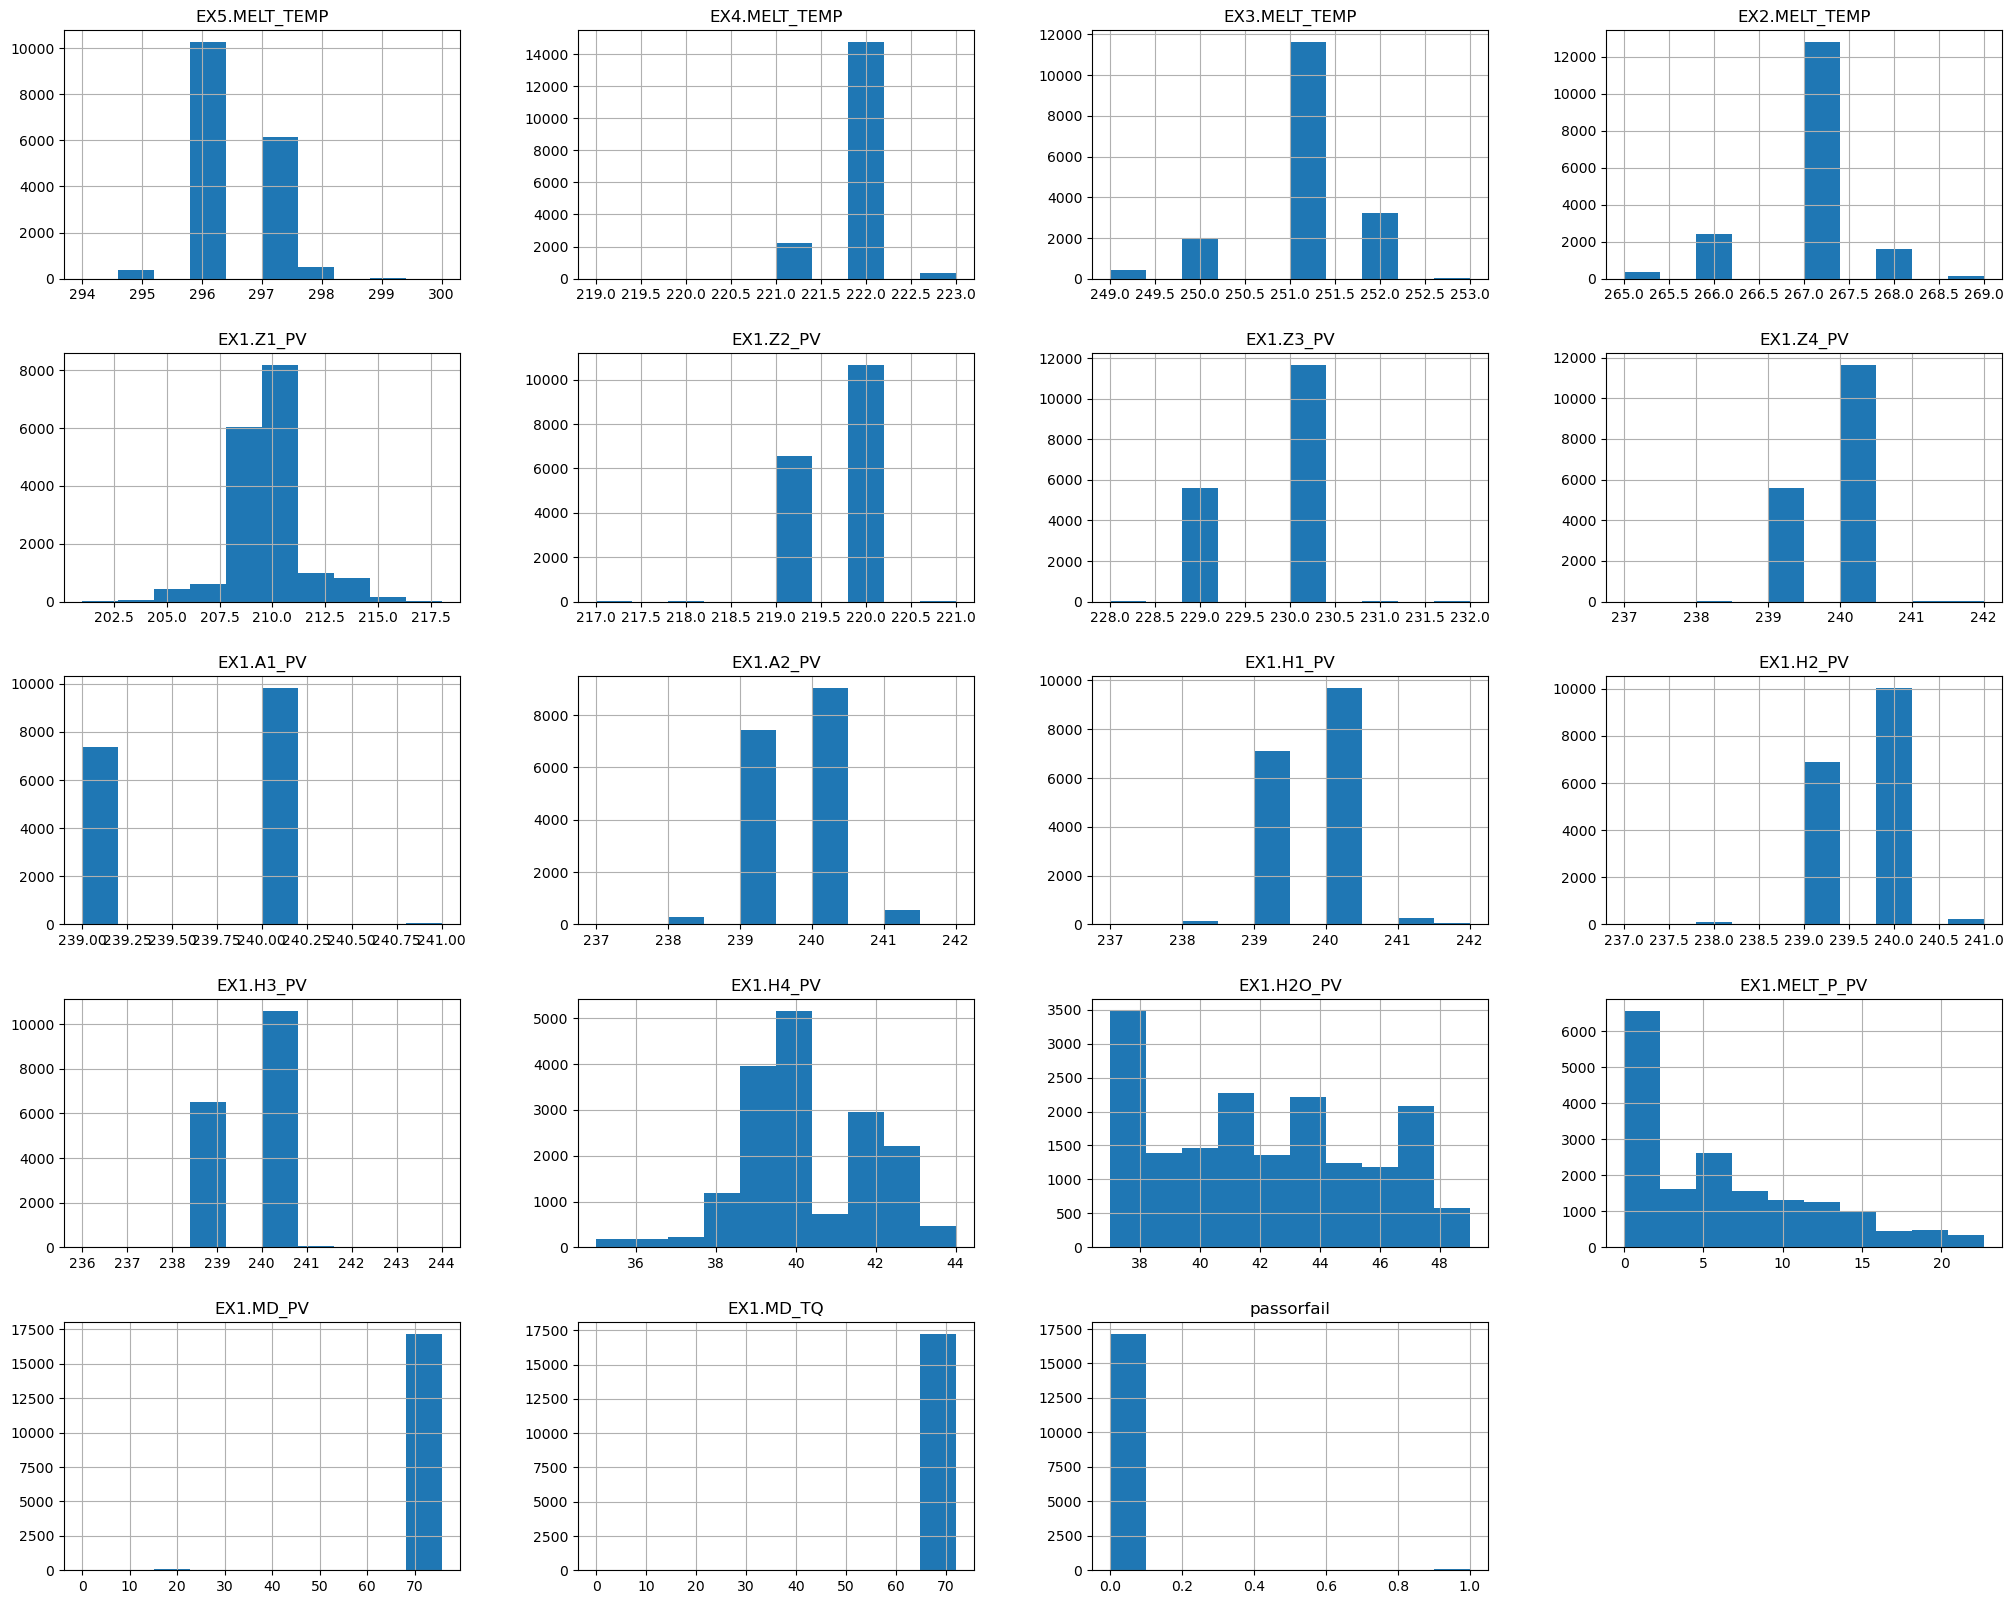

In [13]:
# 변수 분포 시각화
df1.hist(figsize=(25,20))
plt.show()

In [14]:
# EX5.MELT_TEMP ~ EX1.MD_TQ -> X값
# passorfail -> y값
X_len = len(df.columns)-4
cols = list(df.columns[1:X_len])+list([df.columns[-1]])
df2 = df1.loc[:,cols]
df2 = df2.astype(float)
df2 = df2.astype({'passorfail':'float32'})
df2

,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,passorfail
0,297.0,222.0,251.0,267.0,209.0,219.0,229.0,239.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
1,297.0,222.0,251.0,268.0,210.0,219.0,229.0,239.0,240.0,239.0,240.0,240.0,240.0,40.0,41.0,0.0
2,297.0,222.0,251.0,267.0,210.0,219.0,229.0,239.0,240.0,239.0,240.0,240.0,240.0,40.0,41.0,0.0
3,297.0,222.0,251.0,267.0,210.0,219.0,229.0,240.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
4,297.0,222.0,251.0,267.0,210.0,219.0,229.0,239.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17275,296.0,222.0,252.0,267.0,215.0,220.0,230.0,240.0,240.0,240.0,240.0,240.0,240.0,40.0,42.0,NaN
17276,296.0,222.0,252.0,267.0,215.0,220.0,230.0,240.0,240.0,240.0,240.0,240.0,240.0,40.0,42.0,NaN
17277,296.0,222.0,252.0,267.0,214.0,220.0,230.0,240.0,240.0,240.0,240.0,240.0,240.0,40.0,42.0,NaN
17278,296.0,222.0,252.0,267.0,214.0,220.0,230.0,240.0,240.0,240.0,240.0,240.0,240.0,40.0,42.0,NaN


In [15]:
# 결측치 제거
df2 = df2.dropna()
df2

,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,passorfail
0,297.0,222.0,251.0,267.0,209.0,219.0,229.0,239.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
1,297.0,222.0,251.0,268.0,210.0,219.0,229.0,239.0,240.0,239.0,240.0,240.0,240.0,40.0,41.0,0.0
2,297.0,222.0,251.0,267.0,210.0,219.0,229.0,239.0,240.0,239.0,240.0,240.0,240.0,40.0,41.0,0.0
3,297.0,222.0,251.0,267.0,210.0,219.0,229.0,240.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
4,297.0,222.0,251.0,267.0,210.0,219.0,229.0,239.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17259,296.0,222.0,252.0,267.0,211.0,219.0,229.0,240.0,240.0,240.0,239.0,239.0,240.0,40.0,42.0,0.0
17260,296.0,222.0,252.0,267.0,211.0,219.0,230.0,240.0,240.0,240.0,239.0,240.0,240.0,40.0,42.0,0.0
17261,296.0,222.0,252.0,267.0,212.0,219.0,230.0,240.0,240.0,240.0,239.0,239.0,240.0,40.0,42.0,0.0
17262,296.0,222.0,252.0,267.0,212.0,219.0,229.0,240.0,239.0,240.0,239.0,239.0,240.0,40.0,42.0,0.0


In [16]:
# 이상치 값을 0.1%의 상/하한 값으로 대체
for col in df2.columns[0:-1]:
    upper_bound = np.percentile(df2[col], 99.9)
    lower_bound = np.percentile(df2[col], 0.1)
    df2.loc[df2[col] > upper_bound, col] = upper_bound
    df2.loc[df2[col] < lower_bound, col] = lower_bound
df2

,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,passorfail
0,297.0,222.0,251.0,267.0,209.0,219.0,229.0,239.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
1,297.0,222.0,251.0,268.0,210.0,219.0,229.0,239.0,240.0,239.0,240.0,240.0,240.0,40.0,41.0,0.0
2,297.0,222.0,251.0,267.0,210.0,219.0,229.0,239.0,240.0,239.0,240.0,240.0,240.0,40.0,41.0,0.0
3,297.0,222.0,251.0,267.0,210.0,219.0,229.0,240.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
4,297.0,222.0,251.0,267.0,210.0,219.0,229.0,239.0,240.0,239.0,241.0,240.0,240.0,40.0,41.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17259,296.0,222.0,252.0,267.0,211.0,219.0,229.0,240.0,240.0,240.0,239.0,239.0,240.0,40.0,42.0,0.0
17260,296.0,222.0,252.0,267.0,211.0,219.0,230.0,240.0,240.0,240.0,239.0,240.0,240.0,40.0,42.0,0.0
17261,296.0,222.0,252.0,267.0,212.0,219.0,230.0,240.0,240.0,240.0,239.0,239.0,240.0,40.0,42.0,0.0
17262,296.0,222.0,252.0,267.0,212.0,219.0,229.0,240.0,239.0,240.0,239.0,239.0,240.0,40.0,42.0,0.0


In [17]:
# 이상치 처리 후 양품, 불량 수 확인
frauds = df2[df2.passorfail == 1].shape[0]
normal = df2[df2.passorfail == 0].shape[0]
fraud_rate = frauds/(frauds+normal)*100
print(f'양품 수: {normal} 불량 수: {frauds}\n불량률: {fraud_rate}')

양품 수: 17154 불량 수: 110
불량률: 0.6371640407784986


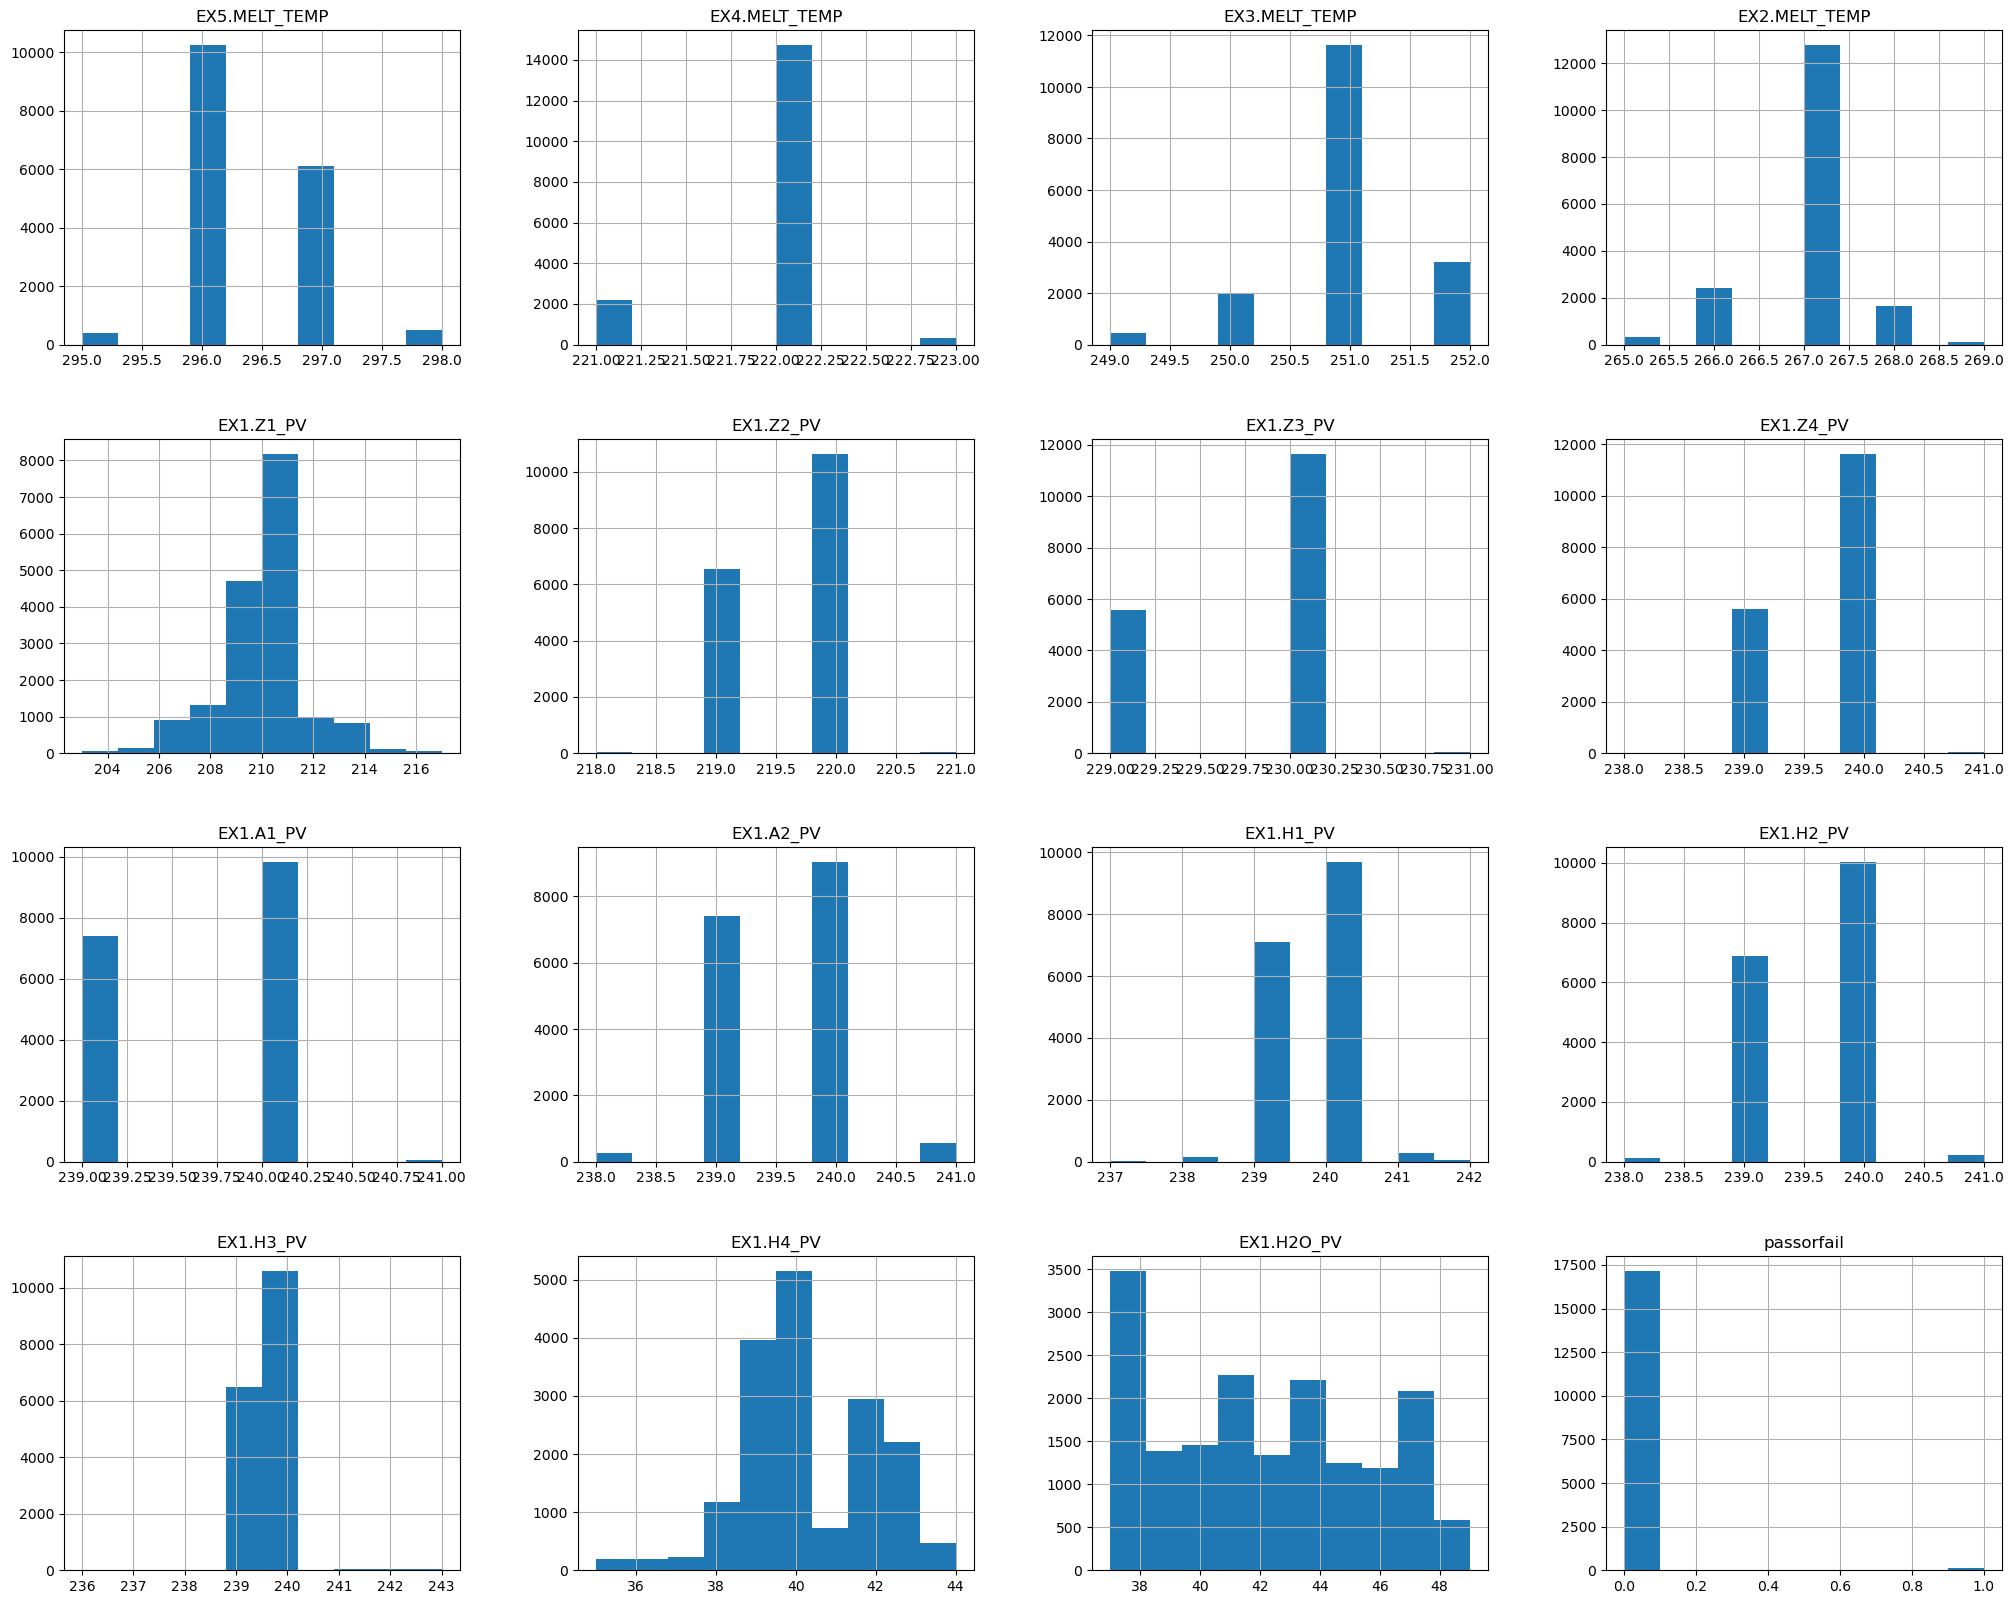

In [18]:
# 이상치 처리 후 변수 분포 시각화
df2.hist(figsize=(25,20))
plt.show()

In [19]:
# t-test
t_test = []
for i, col in enumerate(df2.columns):
    t = stats.ttest_ind(df2[df2.passorfail==1][col], df2[df2.passorfail==0][col], equal_var=False)
    t_test.append([col, t[0], t[1]])
df_ttest = pd.DataFrame(t_test, columns=['col','tvalue', 'pvalue'])
t_list = []
for i in range(len(df_ttest)):
    if df_ttest['pvalue'][i] <= 0.1:
        t_list.append(df_ttest['col'][i])
df3 = df2.loc[:, t_list]
df3

,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,passorfail
0,297.0,222.0,251.0,267.0,209.0,219.0,239.0,240.0,239.0,240.0,240.0,40.0,41.0,0.0
1,297.0,222.0,251.0,268.0,210.0,219.0,239.0,240.0,239.0,240.0,240.0,40.0,41.0,0.0
2,297.0,222.0,251.0,267.0,210.0,219.0,239.0,240.0,239.0,240.0,240.0,40.0,41.0,0.0
3,297.0,222.0,251.0,267.0,210.0,219.0,240.0,240.0,239.0,240.0,240.0,40.0,41.0,0.0
4,297.0,222.0,251.0,267.0,210.0,219.0,239.0,240.0,239.0,240.0,240.0,40.0,41.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17259,296.0,222.0,252.0,267.0,211.0,219.0,240.0,240.0,240.0,239.0,240.0,40.0,42.0,0.0
17260,296.0,222.0,252.0,267.0,211.0,219.0,240.0,240.0,240.0,240.0,240.0,40.0,42.0,0.0
17261,296.0,222.0,252.0,267.0,212.0,219.0,240.0,240.0,240.0,239.0,240.0,40.0,42.0,0.0
17262,296.0,222.0,252.0,267.0,212.0,219.0,240.0,239.0,240.0,239.0,240.0,40.0,42.0,0.0


<Axes: >

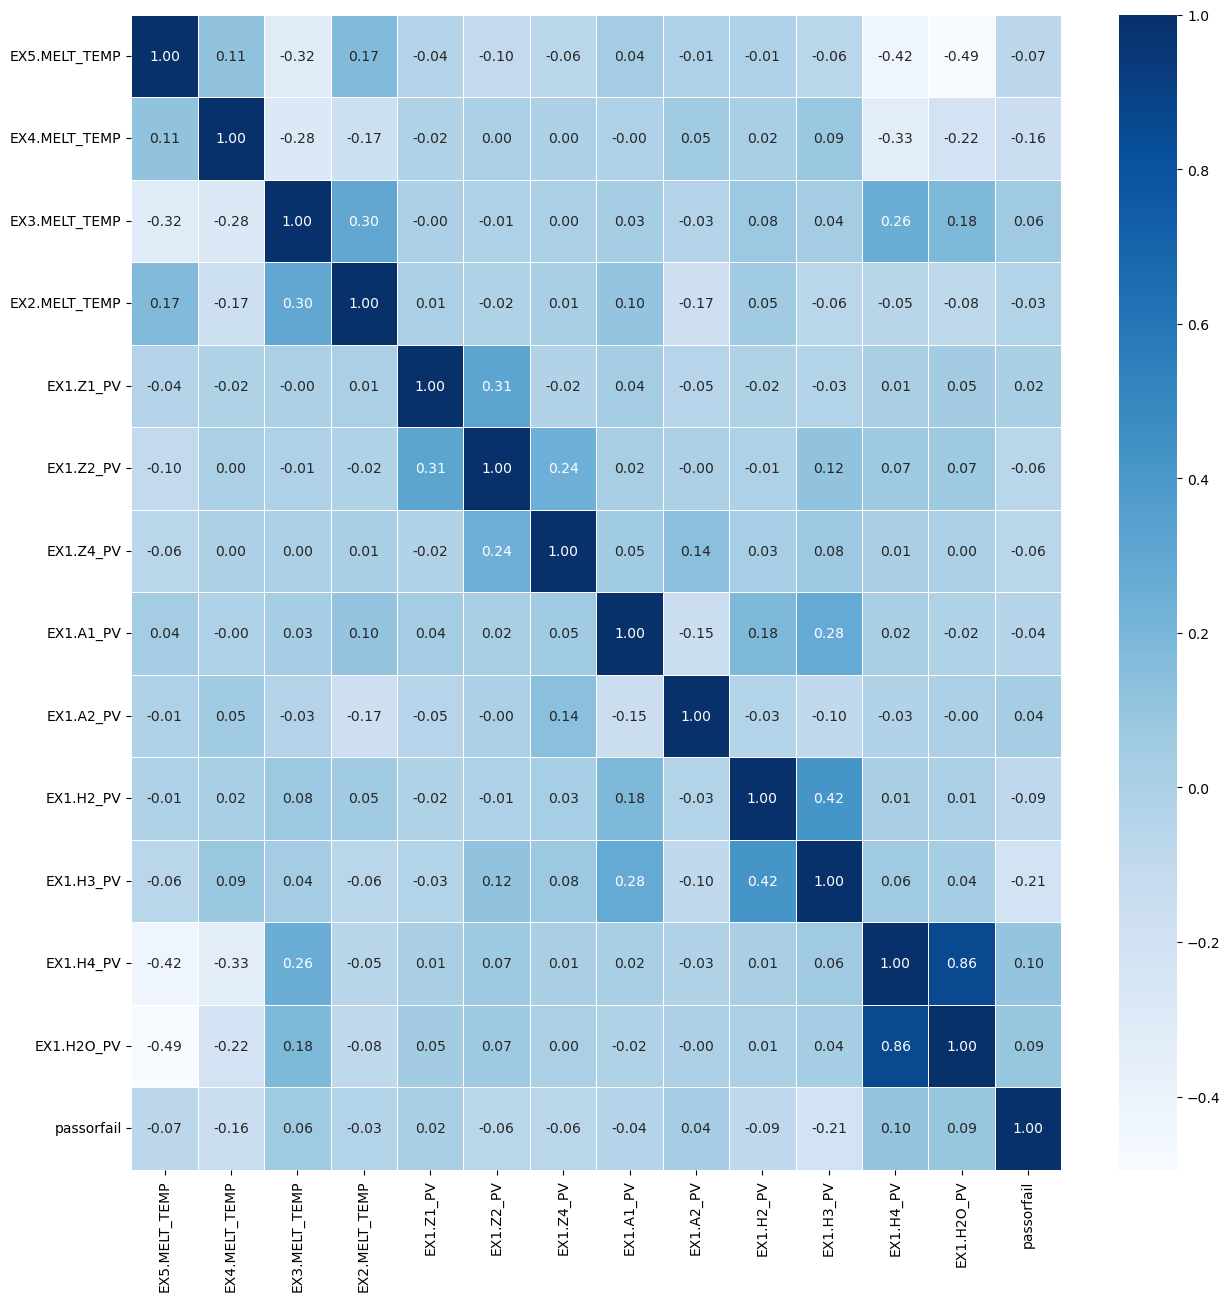

In [20]:
# 상관계수 시각화
plt.figure(figsize=(15,15))
sns.heatmap(data = df3.corr(), annot=True, fmt = '.2f', linewidths=.5, cmap='Blues')

In [22]:
# train, test 데이터 준비
data = df3.loc[:,list(df3.columns)[:-1]]
target = df3.loc[:,list(df3.columns)[-1]].astype(int)
# 학습용 데이터, 테스트 데이터의 비율은 8:2로 진행
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, shuffle=True, stratify=target, random_state=42)
y_train, y_test = np.array(y_train), np.array(y_test)
print('Train :', X_train.shape, 'Test :', X_test.shape)
print('Train :', y_train.shape, 'Test :', y_test.shape)

Train : (13811, 13) Test : (3453, 13)
Train : (13811,) Test : (3453,)


In [23]:
# 스케일러 적용
scaler = MinMaxScaler()
scaler = scaler.fit(X_train)
# 훈련 데이터에 스케일러 적용
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)

In [25]:
kfold = KFold(n_splits=3, shuffle=True)
dt_kf_acc = []
dt = DecisionTreeClassifier()
n_iter = 0
for train_idx, valid_idx in kfold.split(X_train):
    X_train_, X_valid_ = X_train[train_idx], X_train[valid_idx]
    y_train_, y_valid_ = y_train[train_idx], y_train[valid_idx]
    # DecisionTreeClassifier 훈련
    dt.fit(X_train_, y_train_)
    dt_pred = dt.predict(X_valid_)
    dt_acc = accuracy_score(dt_pred, y_valid_)
    n_iter += 1
    dt_kf_acc.append([n_iter, dt_acc, dt])
    print(f'KFold {n_iter} 교차검증 정확도 : {dt_acc}, 학습 데이터 크기:{X_train_.shape[0]}, 검증 데이터 크기:{y_train_.shape[0]}')
dt_kf_acc_sort = dt_kf_acc
dt_kf_acc_sort.sort(key=lambda x : x[1], reverse=True)
# KFold 검증 후 가장 정확도가 높은 모델 선택
dt = dt_kf_acc_sort[0][2]
print(f'교차검증 중 가장 높은 정확도 : KFold {dt_kf_acc_sort[0][0]}, {dt_kf_acc_sort[0][1]}')

KFold 1 교차검증 정확도 : 0.9978279756733276, 학습 데이터 크기:9207, 검증 데이터 크기:9207
KFold 2 교차검증 정확도 : 0.9989139878366637, 학습 데이터 크기:9207, 검증 데이터 크기:9207
KFold 3 교차검증 정확도 : 0.9993482511405605, 학습 데이터 크기:9208, 검증 데이터 크기:9208
교차검증 중 가장 높은 정확도 : KFold 3, 0.9993482511405605


In [26]:
kfold = KFold(n_splits=3, shuffle=True)
rf_kf_acc = []
rf = RandomForestClassifier(random_state=42)
n_iter = 0
for train_idx, valid_idx in kfold.split(X_train):
    X_train_, X_valid_ = X_train[train_idx], X_train[valid_idx]
    y_train_, y_valid_ = y_train[train_idx], y_train[valid_idx]
    # RandomForestClassifier 훈련
    rf.fit(X_train_, y_train_)
    rf_pred = rf.predict(X_valid_)
    rf_acc = accuracy_score(rf_pred, y_valid_)
    n_iter += 1
    rf_kf_acc.append([n_iter, rf_acc, rf])
    print(f'KFold {n_iter} 교차검증 정확도 : {rf_acc}, 학습 데이터 크기:{X_train_.shape[0]}, 검증 데이터 크기:{y_train_.shape[0]}')
rf_kf_acc_sort = rf_kf_acc
rf_kf_acc_sort.sort(key=lambda x : x[1], reverse=True)
# KFold 검증 후 가장 정확도가 높은 모델 선택
rf = rf_kf_acc_sort[0][2]
print(f'교차검증 중 가장 높은 정확도 : KFold {rf_kf_acc_sort[0][0]}, {rf_kf_acc_sort[0][1]}')

KFold 1 교차검증 정확도 : 0.9984795829713293, 학습 데이터 크기:9207, 검증 데이터 크기:9207
KFold 2 교차검증 정확도 : 0.9980451781059948, 학습 데이터 크기:9207, 검증 데이터 크기:9207
KFold 3 교차검증 정확도 : 0.9989137519009341, 학습 데이터 크기:9208, 검증 데이터 크기:9208
교차검증 중 가장 높은 정확도 : KFold 3, 0.9989137519009341


In [39]:
kfold = KFold(n_splits=3, shuffle=True)
ada_kf_acc = []
ada = AdaBoostClassifier(random_state=42)
n_iter = 0
for train_idx, valid_idx in kfold.split(X_train):
    X_train_, X_valid_ = X_train[train_idx], X_train[valid_idx]
    y_train_, y_valid_ = y_train[train_idx], y_train[valid_idx]
    # AdaBoostClassifier 훈련
    ada.fit(X_train_, y_train_)
    ada_pred = dt.predict(X_valid_)
    ada_acc = accuracy_score(ada_pred, y_valid_)
    n_iter += 1
    print(f'KFold {n_iter} 교차검증 정확도 : {ada_acc}, 학습 데이터 크기:{X_train_.shape[0]}, 검증 데이터 크기:{y_train_.shape[0]}')   
    ada_kf_acc.append([n_iter, ada_acc, ada])
    
ada_kf_acc_sort = ada_kf_acc
ada_kf_acc_sort.sort(key=lambda x : x[1], reverse=True)
# KFold 검증 후 가장 정확도가 높은 모델 선택
ada = ada_kf_acc_sort[0][2]
print(f'교차검증 중 가장 높은 정확도 : KFold {ada_kf_acc_sort[0][0]}, {ada_kf_acc_sort[0][1]}')

KFold 1 교차검증 정확도 : 0.9991311902693311, 학습 데이터 크기:9207, 검증 데이터 크기:9207
KFold 2 교차검증 정확도 : 0.9993483927019983, 학습 데이터 크기:9207, 검증 데이터 크기:9207
KFold 3 교차검증 정확도 : 0.9993482511405605, 학습 데이터 크기:9208, 검증 데이터 크기:9208
교차검증 중 가장 높은 정확도 : KFold 2, 0.9993483927019983


In [40]:
# 모든 Fold 별 결과 확인
total_fold_df = pd.DataFrame({
    'Decision Tree':[ada_kf_acc[0][1], ada_kf_acc[1][1], ada_kf_acc[2][1]],
    'Random Forest':[rf_kf_acc[0][1], rf_kf_acc[1][1], rf_kf_acc[2][1]],
    'Adaboost':[ada_kf_acc[0][1], ada_kf_acc[1][1], ada_kf_acc[2][1]]},
                             index=['Fold1', 'Fold2', 'Fold3'])
total_fold_df

,Decision Tree,Random Forest,Adaboost
Fold1,0.999348,0.998914,0.999348
Fold2,0.999348,0.998480,0.999348
Fold3,0.999131,0.998045,0.999131


DecisionTreeClassifier()
precision: 0.9565217391304348 recall: 1.0
F1-Score: 0.9777777777777777 Accuracy: 0.9997103967564437


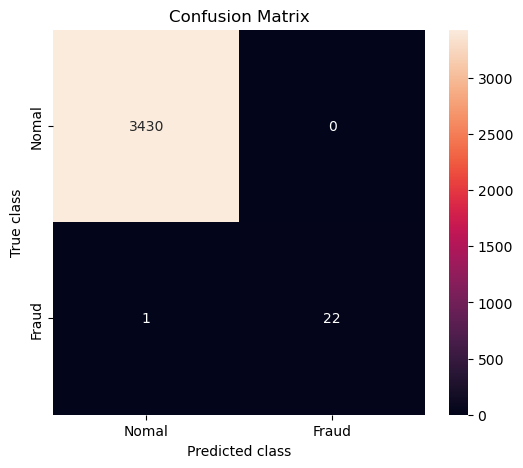

In [41]:
# 테스트셋으로 모델 테스트
dt_pred = dt.predict(X_test)
dt_pred = np.choose(dt_pred, [0, 1]).astype(float)
result = {}
# 테스트 정확도 출력
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_acc = accuracy_score(dt_pred, y_test)
dt_cm = confusion_matrix(dt_pred, y_test)
result['DecisionTree'] = {'precision':dt_precision, 'recall':dt_recall, 'f1-score':dt_f1, 'accuracy':dt_acc}
print(f'{dt}\nprecision: {dt_precision} recall: {dt_recall}\nF1-Score: {dt_f1} Accuracy: {dt_acc}')
# Confusion Matrix 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(dt_cm, xticklabels=['Nomal', 'Fraud'], yticklabels=['Nomal', 'Fraud'], annot=True, fmt="d");
plt.title("Confusion Matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

RandomForestClassifier(random_state=42)
precision: 0.9565217391304348 recall: 1.0
F1-Score: 0.9777777777777777 Accuracy: 0.9997103967564437


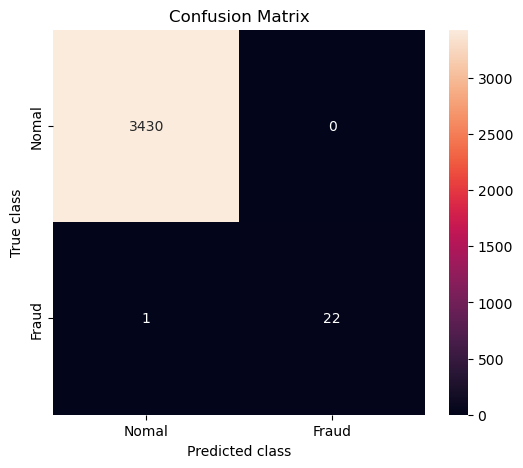

In [42]:
# 훈련된 모델 테스트
rf_pred = rf.predict(X_test)
rf_pred = np.choose(rf_pred, [0, 1]).astype(float)
# 테스트 정확도 출력
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_acc = accuracy_score(rf_pred, y_test)
rf_cm = confusion_matrix(rf_pred, y_test)
result['RandomForest'] = {'precision':rf_precision, 'recall':rf_recall, 'f1-score':rf_f1, 'accuracy':rf_acc}
print(f'{rf}\nprecision: {rf_precision} recall: {rf_recall}\nF1-Score: {rf_f1} Accuracy: {rf_acc}')
# Confusion Matrix 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, xticklabels=['Nomal', 'Fraud'], yticklabels=['Nomal', 'Fraud'], annot=True, fmt="d");
plt.title("Confusion Matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

AdaBoostClassifier(random_state=42)
precision: 0.95 recall: 0.8636363636363636
F1-Score: 0.9047619047619048 Accuracy: 0.9988415870257746


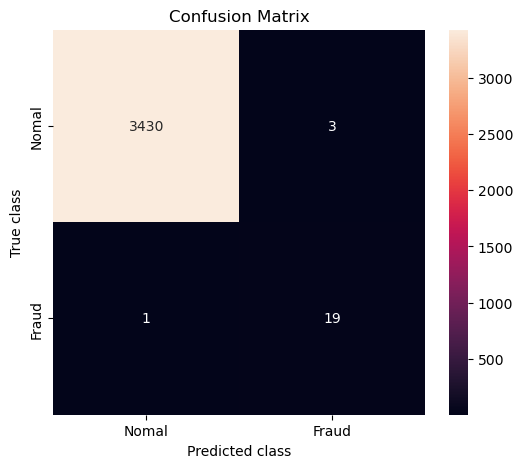

In [43]:
# 훈련된 모델 테스트
ada_pred = ada.predict(X_test)
ada_pred = np.choose(ada_pred, [0, 1]).astype(float)
# 테스트 정확도 출력
ada_precision = precision_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)
ada_f1 = f1_score(y_test, ada_pred)
ada_acc = accuracy_score(ada_pred, y_test)
ada_cm = confusion_matrix(ada_pred, y_test)
result['AdaBoost'] = {'precision':ada_precision, 'recall':ada_recall, 'f1-score':ada_f1, 'accuracy':ada_acc}
print(f'{ada}\nprecision: {ada_precision} recall: {ada_recall}\nF1-Score: {ada_f1} Accuracy: {ada_acc}')
# Confusion Matrix 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(ada_cm, xticklabels=['Nomal', 'Fraud'], yticklabels=['Nomal', 'Fraud'], annot=True, fmt="d");
plt.title("Confusion Matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [44]:
# 모델별 학습 결과 출력
pd.DataFrame(result).T

,precision,recall,f1-score,accuracy
DecisionTree,0.956522,1.000000,0.977778,0.999710
RandomForest,0.956522,1.000000,0.977778,0.999710
AdaBoost,0.950000,0.863636,0.904762,0.998842


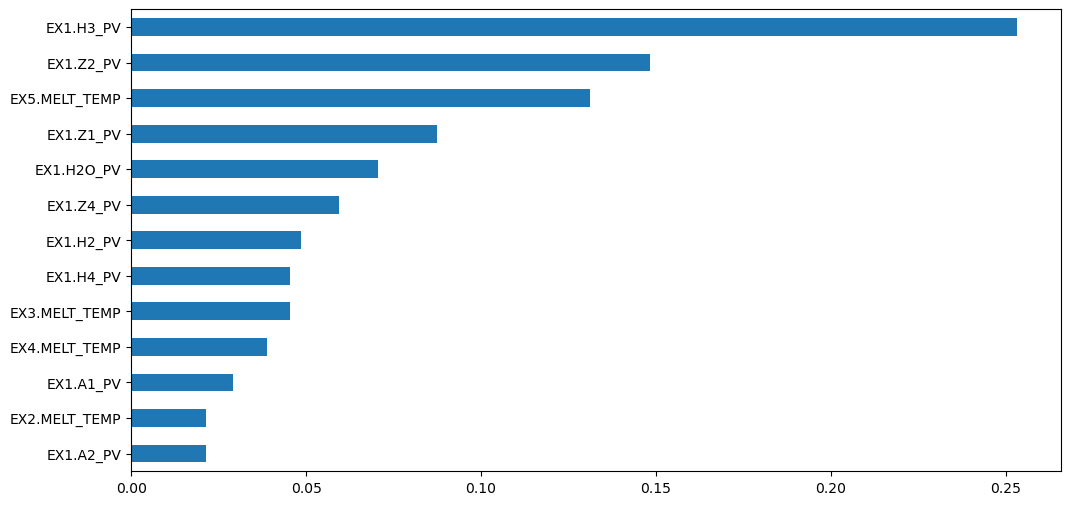

In [45]:
# RandomForest Feature importances 시각화
rf_importance = rf.feature_importances_
rf_importances = pd.Series(rf_importance, data.columns)
plt.figure(figsize=(12, 6))
rf_importances.sort_values().plot.barh();